# T66 — End-Permian CO₂-sensitivity ensemble


**Cluster J: Paleoclimate.**
*Based on:* pySCION (Merdith et al. 2025); ensemble computed by A.M. for this study.

**Climate response of the end-Permian (252 Ma) world to a CO₂ sweep across two orders of magnitude. Loads the compact stacked PLASIM-GENIE output bundled with the suite, plots surface-air temperature at three representative CO₂ levels, the zonal-mean SAT-vs-latitude fan coloured by CO₂, and the global-mean GAST-vs-CO₂ sensitivity curve.**

## What this notebook produces

PLASIM-GENIE (PLASIM atmosphere + GOLDSTEIN ocean; Holden et al. 2016) forced by SCION-derived CO₂ scenarios was run at the 252 Ma paleogeography for ten CO₂ concentrations from 140 to 35840 ppm — pre-industrial to a runaway end-Permian scenario. This notebook reproduces the headline science figure (3-panel SAT map across three CO₂ levels), the latitudinal temperature-profile fan (one curve per CO₂), and the global climate-sensitivity scatter (GAST vs ln-CO₂ with regression slope) from a 400 KB bundled compact NetCDF — versus the 1.5 GB of raw model output the full ensemble produces.

**Audience**: postgrad → researcher.
**Difficulty**: ★★★.

## Learning objectives

- Load a multi-CO₂ stacked NetCDF (dims `co2_ppm × lat × lon`) with `xarray` and select snapshots by CO₂.
- Compute area-weighted global-mean surface temperature (GAST) under a `cos(latitude)` weight.
- Render a SAT map with pyGMT `grdimage` using a custom diverging palette appropriate for the −40 to +40 °C range.
- Fit a logarithmic climate-sensitivity curve (ΔGAST per CO₂ doubling) from the ensemble.

## Prerequisites and runtime

- **Data**: `data/plasim_genie_permian/plasim_genie_252Ma_equilibrium.nc` (bundled, 350 KB).
- **Python**: `xarray`, `pygmt`, `numpy`, `matplotlib`, `cmcrameri`.
- **Runtime**: \~30 seconds.

*Reference:* <https://github.com/bjwmills/pySCION>


## Data availability

This notebook reads the compact `data/plasim_genie_permian/plasim_genie_252Ma_equilibrium.nc` bundle, produced by stripping the last-year (year 3000) snapshot from each of Andrew Merdith's ten 252 Ma PLASIM-GENIE runs and stacking on a `co2_ppm` axis. Full model output (1.5 GB, 30 yearly snapshots per CO₂ level, all 100+ PLASIM variables) is available from Andrew Merdith on request.

> Mills, B.J.W., Donnadieu, Y., Goddéris, Y. (2021). Spatial continuous integration of Phanerozoic global biogeochemistry and climate. *Gondwana Research* 100, 73-86. https://doi.org/10.1016/j.gr.2021.02.011

End-Permian 252 Ma ensemble: bundled with this tutorial collection.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
from pathlib import Path
import numpy as np, xarray as xr
import pygmt
from cmcrameri import cm as cmc
from IPython.display import display, HTML

# Library versions (printed for reproducibility)
try:
    import gplately, pygmt as _pg, pygplates
    print(f"gplately {gplately.__version__}  pygmt {_pg.version}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")

import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str(_Path("Notebooks").resolve()))
from paleoclimate_helpers import refine_for_plot


version probe failed: module 'pygmt' has no attribute 'version'


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
PLASIM_GENIE_NC             = "data/plasim_genie_permian/plasim_genie_252Ma_equilibrium.nc"
MODEL_NAME           = "PLASIM_GENIE_MER25rev6"
RECONSTRUCTION_TIME  = 252.0          # Ma — end-Permian
CO2_PANEL_VALUES     = (280, 1120, 17920)   # ppm — three representative scenarios
SAT_RANGE            = (-40, 40)      # °C — colour-bar limits
# ============================================================================


## 1. Load the compact bundle

In [3]:
# Cell 2 — load
ds = xr.open_dataset(PLASIM_GENIE_NC)
print(ds)
print(f"\nCO2 levels: {ds.co2_ppm.values.tolist()} ppm")


<xarray.Dataset> Size: 820kB
Dimensions:            (co2_ppm: 10, latitude: 32, longitude: 64)
Coordinates:
  * co2_ppm            (co2_ppm) int32 40B 140 280 560 1120 ... 8960 17920 35840
  * latitude           (latitude) float32 128B 85.76 80.27 ... -80.27 -85.76
  * longitude          (longitude) float32 256B 0.0 5.625 11.25 ... 348.8 354.4
Data variables:
    SAT                (co2_ppm, latitude, longitude) float32 82kB ...
    surface_T          (co2_ppm, latitude, longitude) float32 82kB ...
    sea_ice_cover      (co2_ppm, latitude, longitude) float32 82kB ...
    sea_ice_thickness  (co2_ppm, latitude, longitude) float32 82kB ...
    snow_depth         (co2_ppm, latitude, longitude) float32 82kB ...
    surface_albedo     (co2_ppm, latitude, longitude) float32 82kB ...
    landsea_mask       (co2_ppm, latitude, longitude) float32 82kB ...
    orography          (co2_ppm, latitude, longitude) float32 82kB ...
    top_thermal        (co2_ppm, latitude, longitude) float32 82kB ...

## 2. Per-CO₂ surface-air temperature maps (3-panel)

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


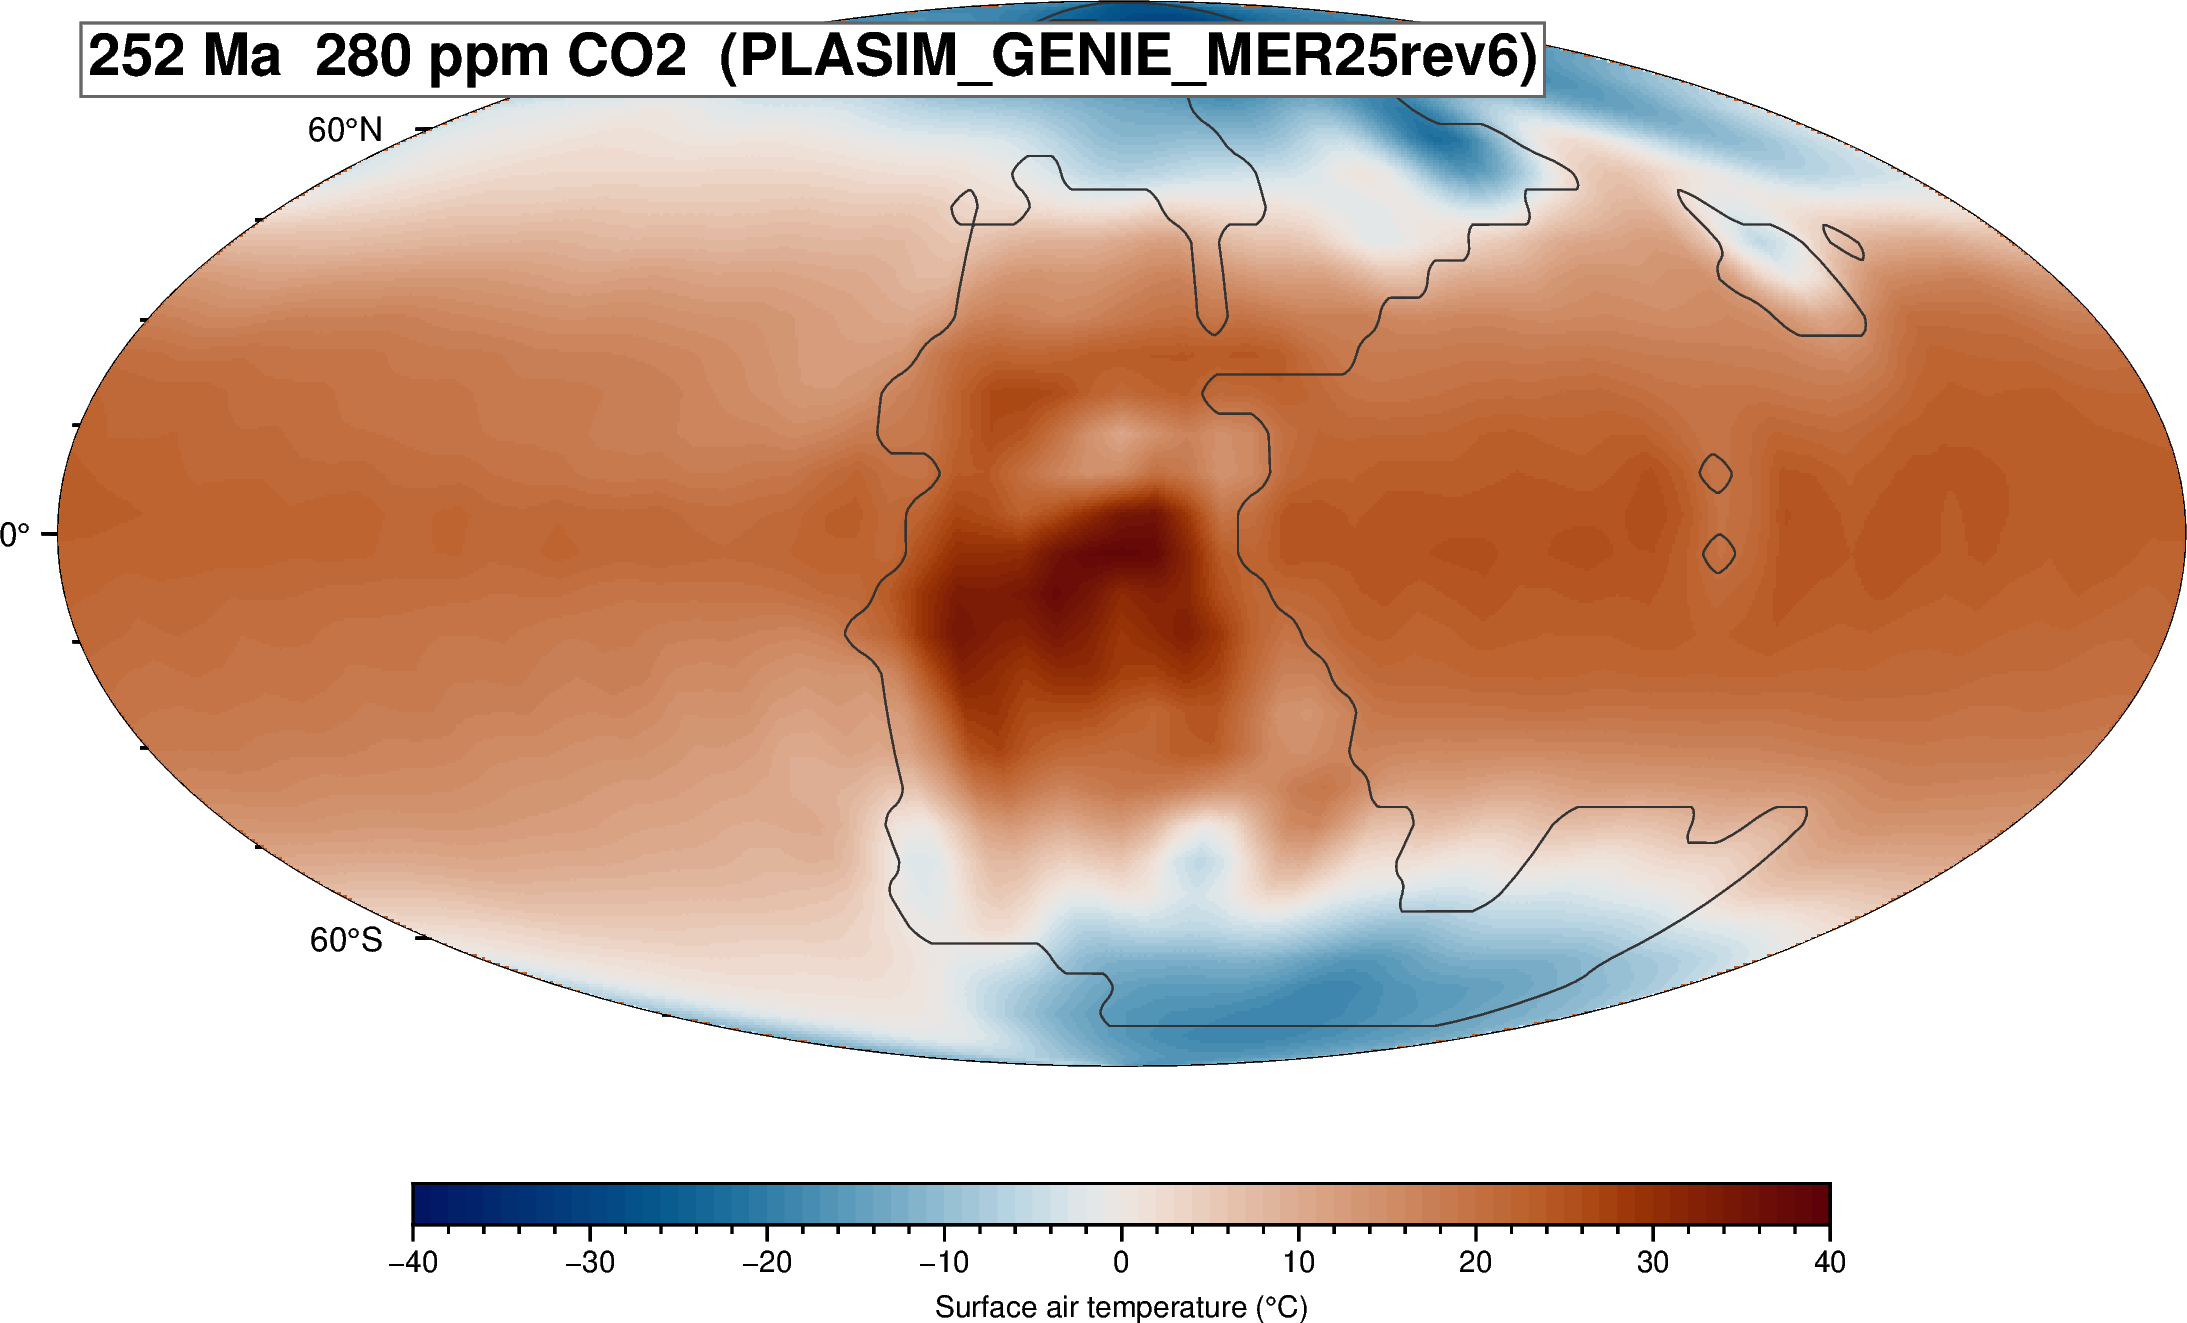

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


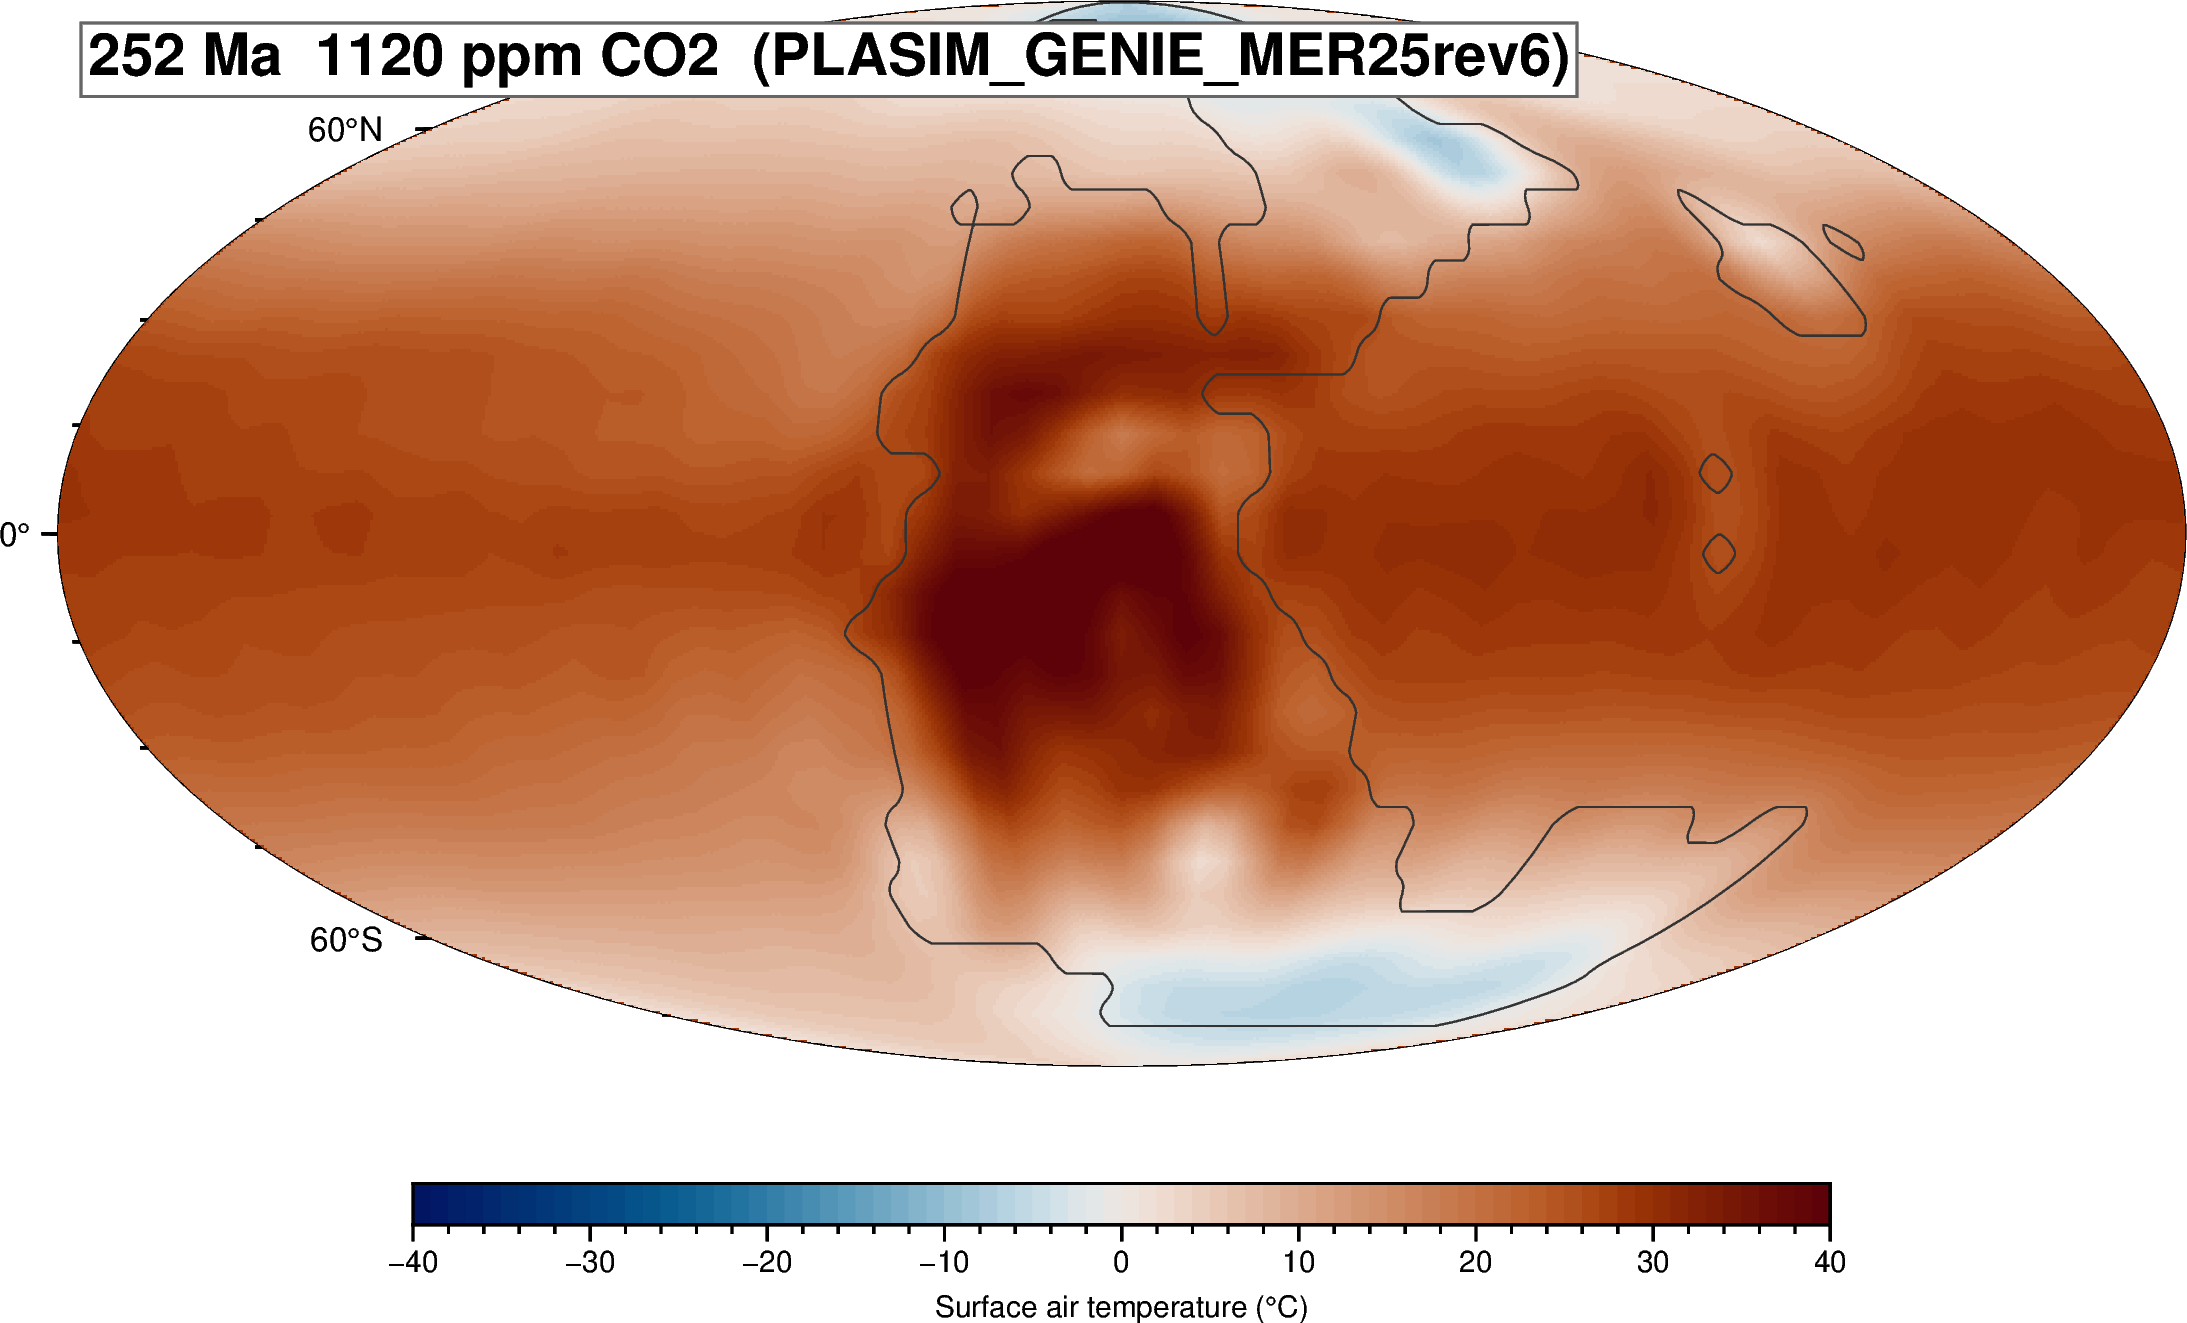

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


grdcontour [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


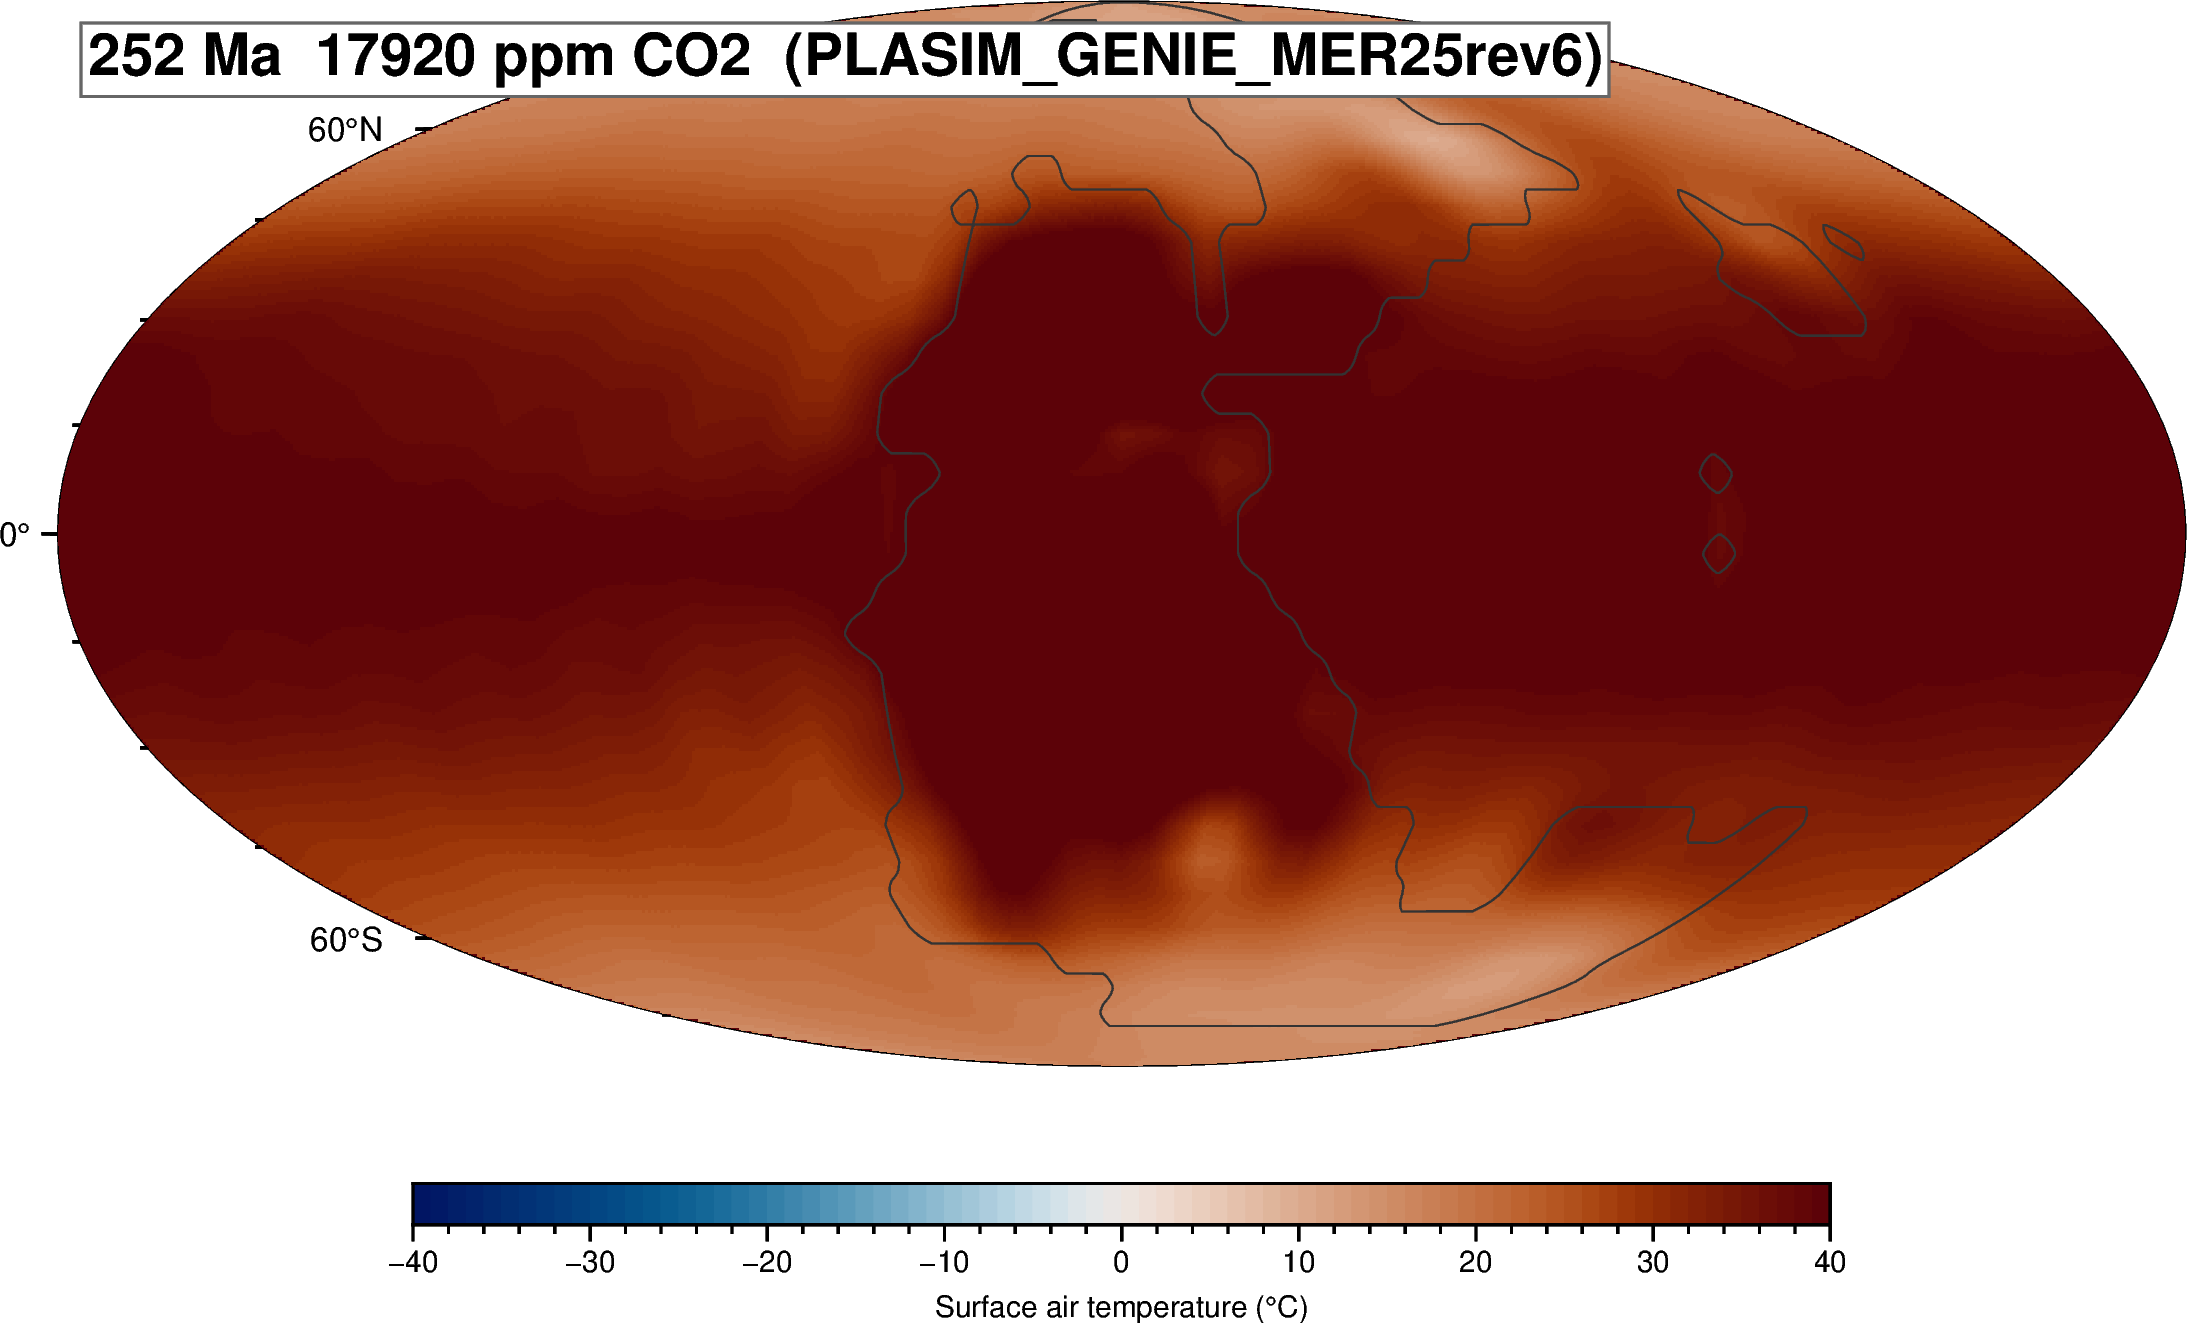

In [4]:
# Cell 3 — render
for co2 in CO2_PANEL_VALUES:
    sat = ds["SAT"].sel(co2_ppm=co2)
    # PLASIM longitude is 0..360; pyGMT prefers -180..180. Roll to GMT convention.
    sat_da = sat.assign_coords(longitude=((sat.longitude + 180) % 360 - 180)).sortby("longitude")

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/18c", frame=["af"])
    pygmt.makecpt(cmap="vik", series=[SAT_RANGE[0], SAT_RANGE[1], 1], reverse=False, background="o")
    fig.grdimage(refine_for_plot(sat_da, lon_name="longitude", lat_name="latitude"), cmap=True)
    fig.colorbar(frame="af+lSurface air temperature (°C)",
                 position="JBC+w12c/0.35c+h+o0/1c")
    # Model's own land-sea-mask contour. NEVER fall back to fig.coast:
    # coast draws PRESENT-DAY GSHHG coastlines, which are geographically wrong
    # on a 252 Ma paleo map. The mask is 3-D (co2_ppm x lat x lon) in the
    # bundle so we slice out one CO2 level (identical across CO2 dim) before
    # rolling longitude + contouring.
    if "landsea_mask" in ds.data_vars:
        _lsm = ds["landsea_mask"]
        if "co2_ppm" in _lsm.dims:
            _lsm = _lsm.isel(co2_ppm=0)  # mask is CO2-independent
        _lsm_da = _lsm.assign_coords(
            longitude=((_lsm.longitude + 180) % 360 - 180)
        ).sortby("longitude")
        fig.grdcontour(
            refine_for_plot(_lsm_da, lon_name="longitude", lat_name="latitude"),
            levels=[0.5], pen="0.4p,gray20",
        )
    else:
        print("  WARN: no landsea_mask in bundle — skipping coastline overlay "
              "(will NOT draw modern GSHHG on a paleo map)")
    fig.text(text=f"{RECONSTRUCTION_TIME:.0f} Ma  {co2} ppm CO2  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=900)
    display(HTML('<div style="height:1cm"></div>'))


## 3. Zonal-mean SAT vs latitude — coloured by CO₂

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


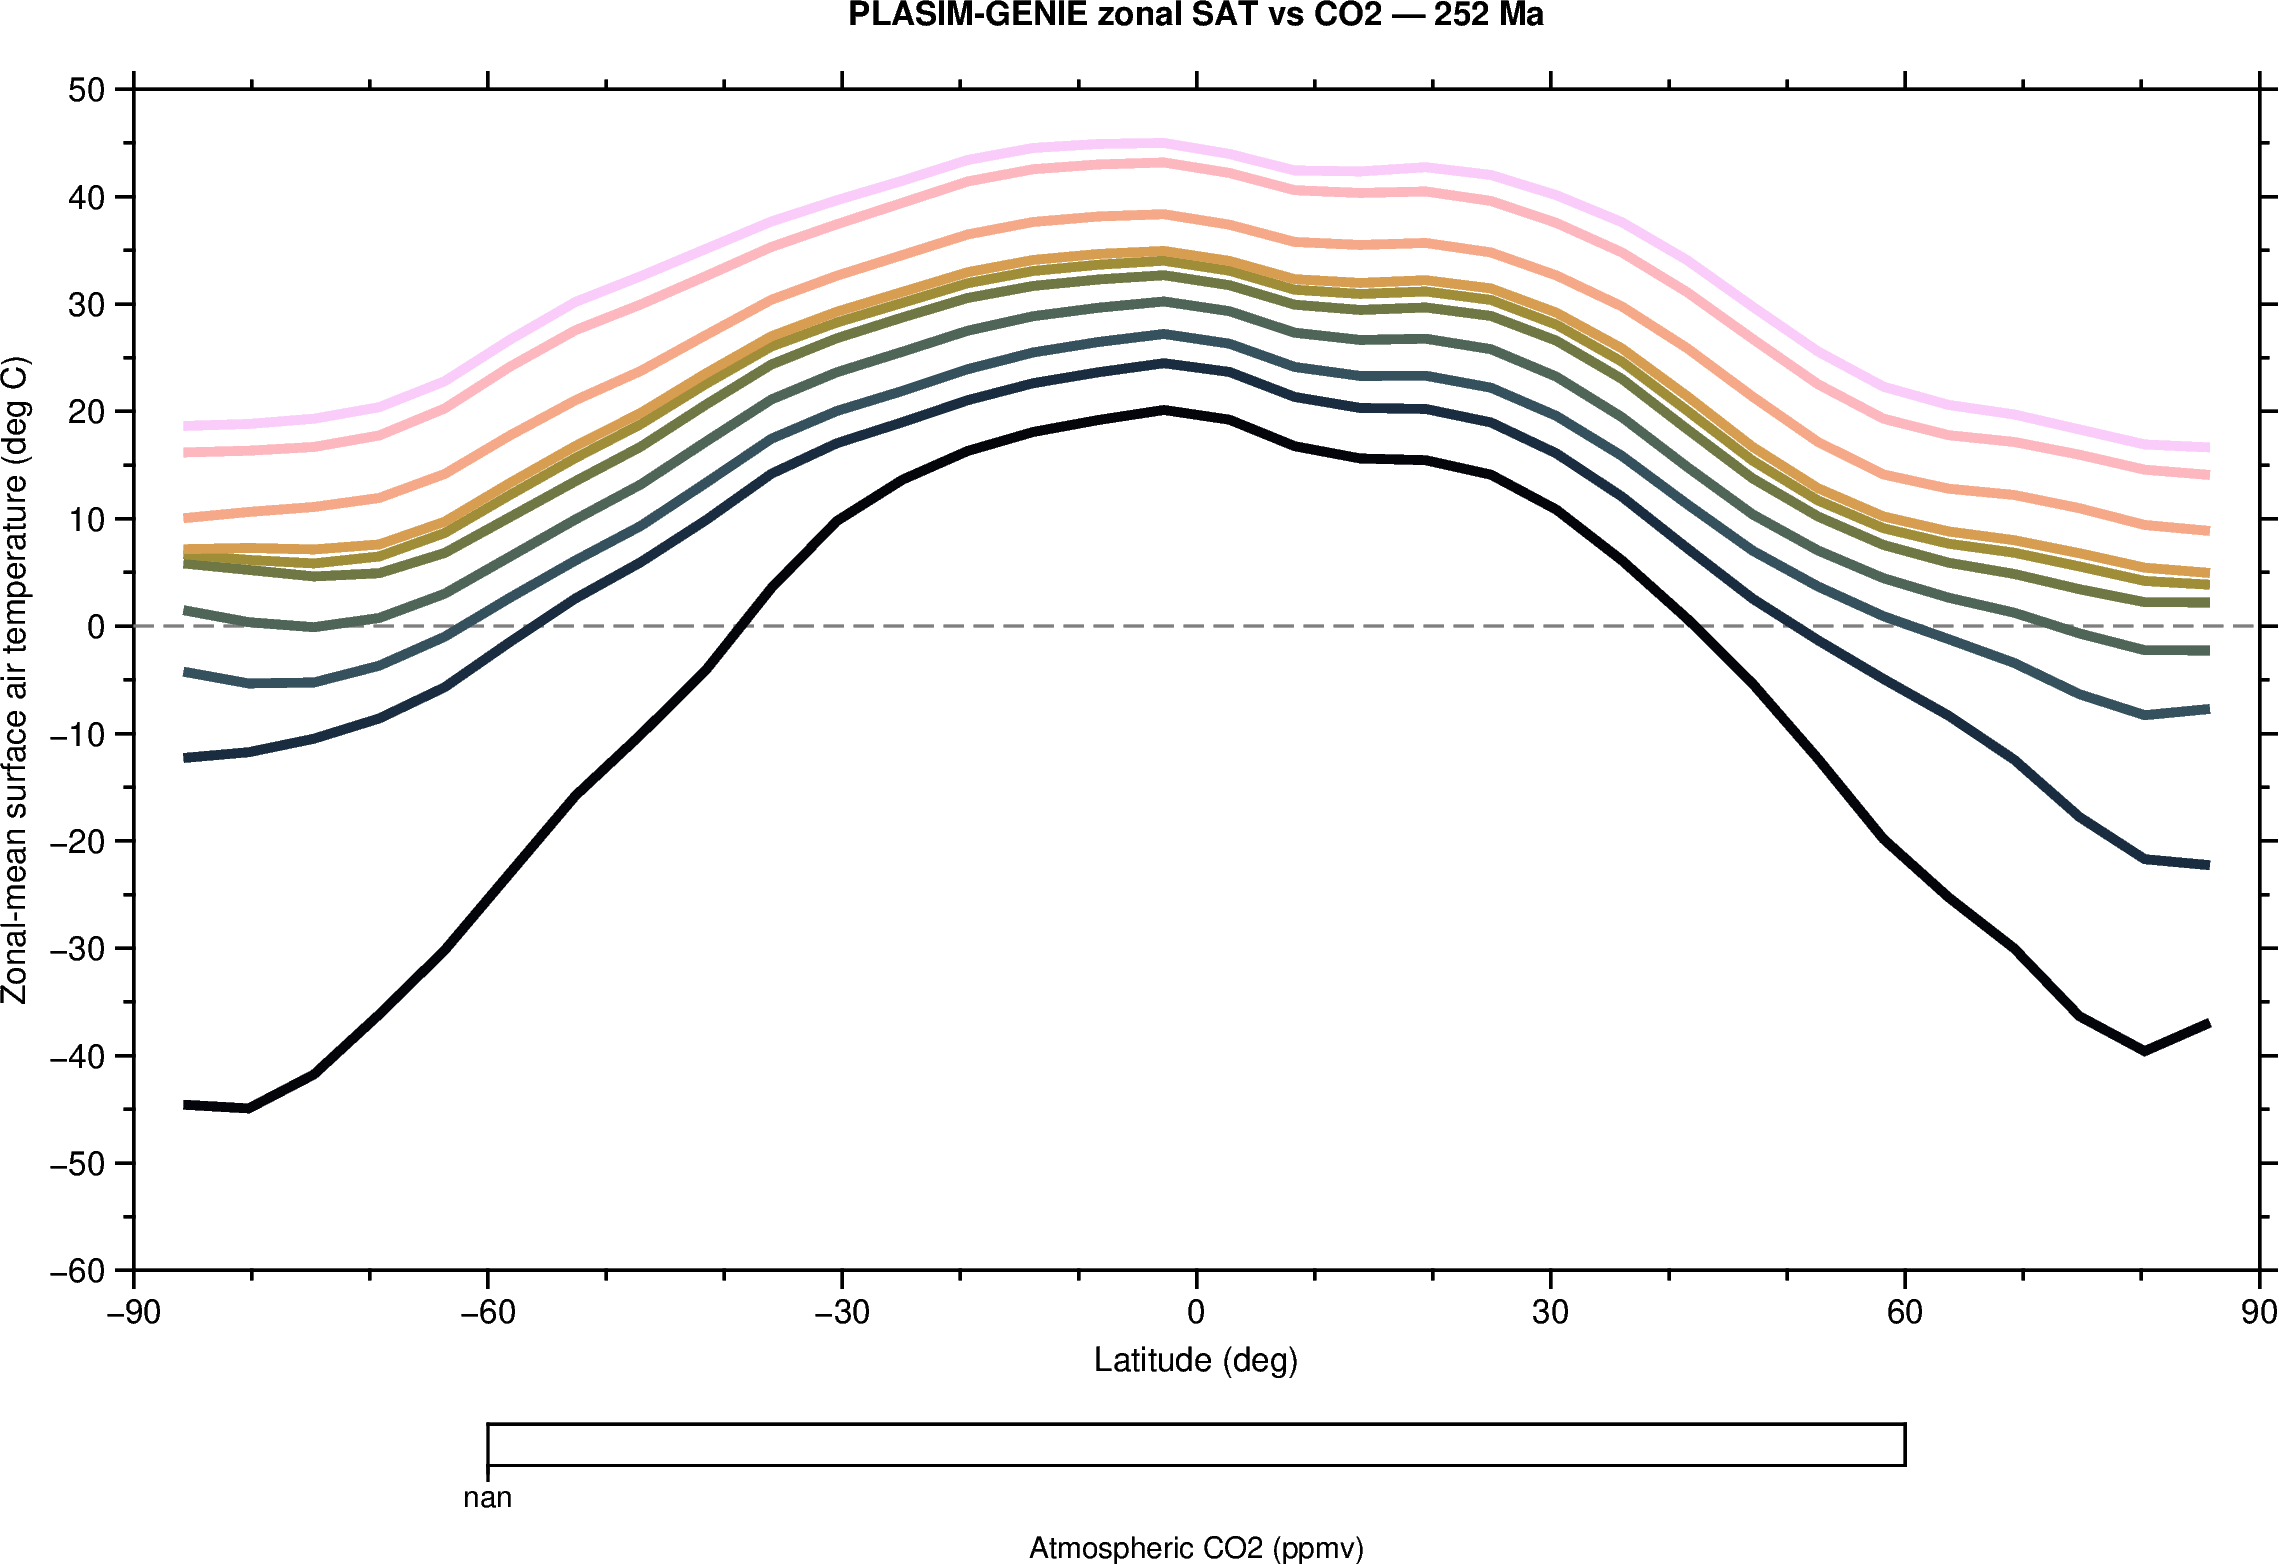

In [5]:
# Cell 4 — zonal-mean fan (pure pyGMT)
# Area-weighted zonal mean SAT
sat_zonal = ds["SAT"].mean(dim="longitude")  # (co2_ppm, lat)
lats      = ds["latitude"].values

base        = cmc.batlowK
co2_vals    = ds.co2_ppm.values
norm_levels = np.linspace(0, 1, len(co2_vals))

def _hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

fig = pygmt.Figure()
fig.basemap(region=[-90, 90, -60, 50], projection="X18c/10c",
            frame=["WSne+tPLASIM-GENIE zonal SAT vs CO2 — 252 Ma",
                   "xa30f10+lLatitude (deg)",
                   "ya10f5+lZonal-mean surface air temperature (deg C)"])
# Zero reference line
fig.plot(x=[-90, 90], y=[0, 0], pen="0.6p,gray50,dashed")
# One line per CO2 level, coloured by CO2 rank on the batlowK ramp
for i, co2 in enumerate(co2_vals):
    colour = _hex(base(norm_levels[i])[:3])
    fig.plot(x=lats, y=sat_zonal.isel(co2_ppm=i).values,
             pen=f"2.2p,{colour}")
# Log-CO2 colour bar keyed to the same ramp used for the lines
pygmt.makecpt(cmap="batlowK",
              series=[float(co2_vals.min()), float(co2_vals.max())],
              continuous=True, log=True)
fig.colorbar(frame="af+lAtmospheric CO2 (ppmv)",
             position="JBC+w12c/0.35c+h+o0/1.3c")
fig.show(width=800)

## 4. Climate sensitivity — GAST vs ln(CO₂)

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


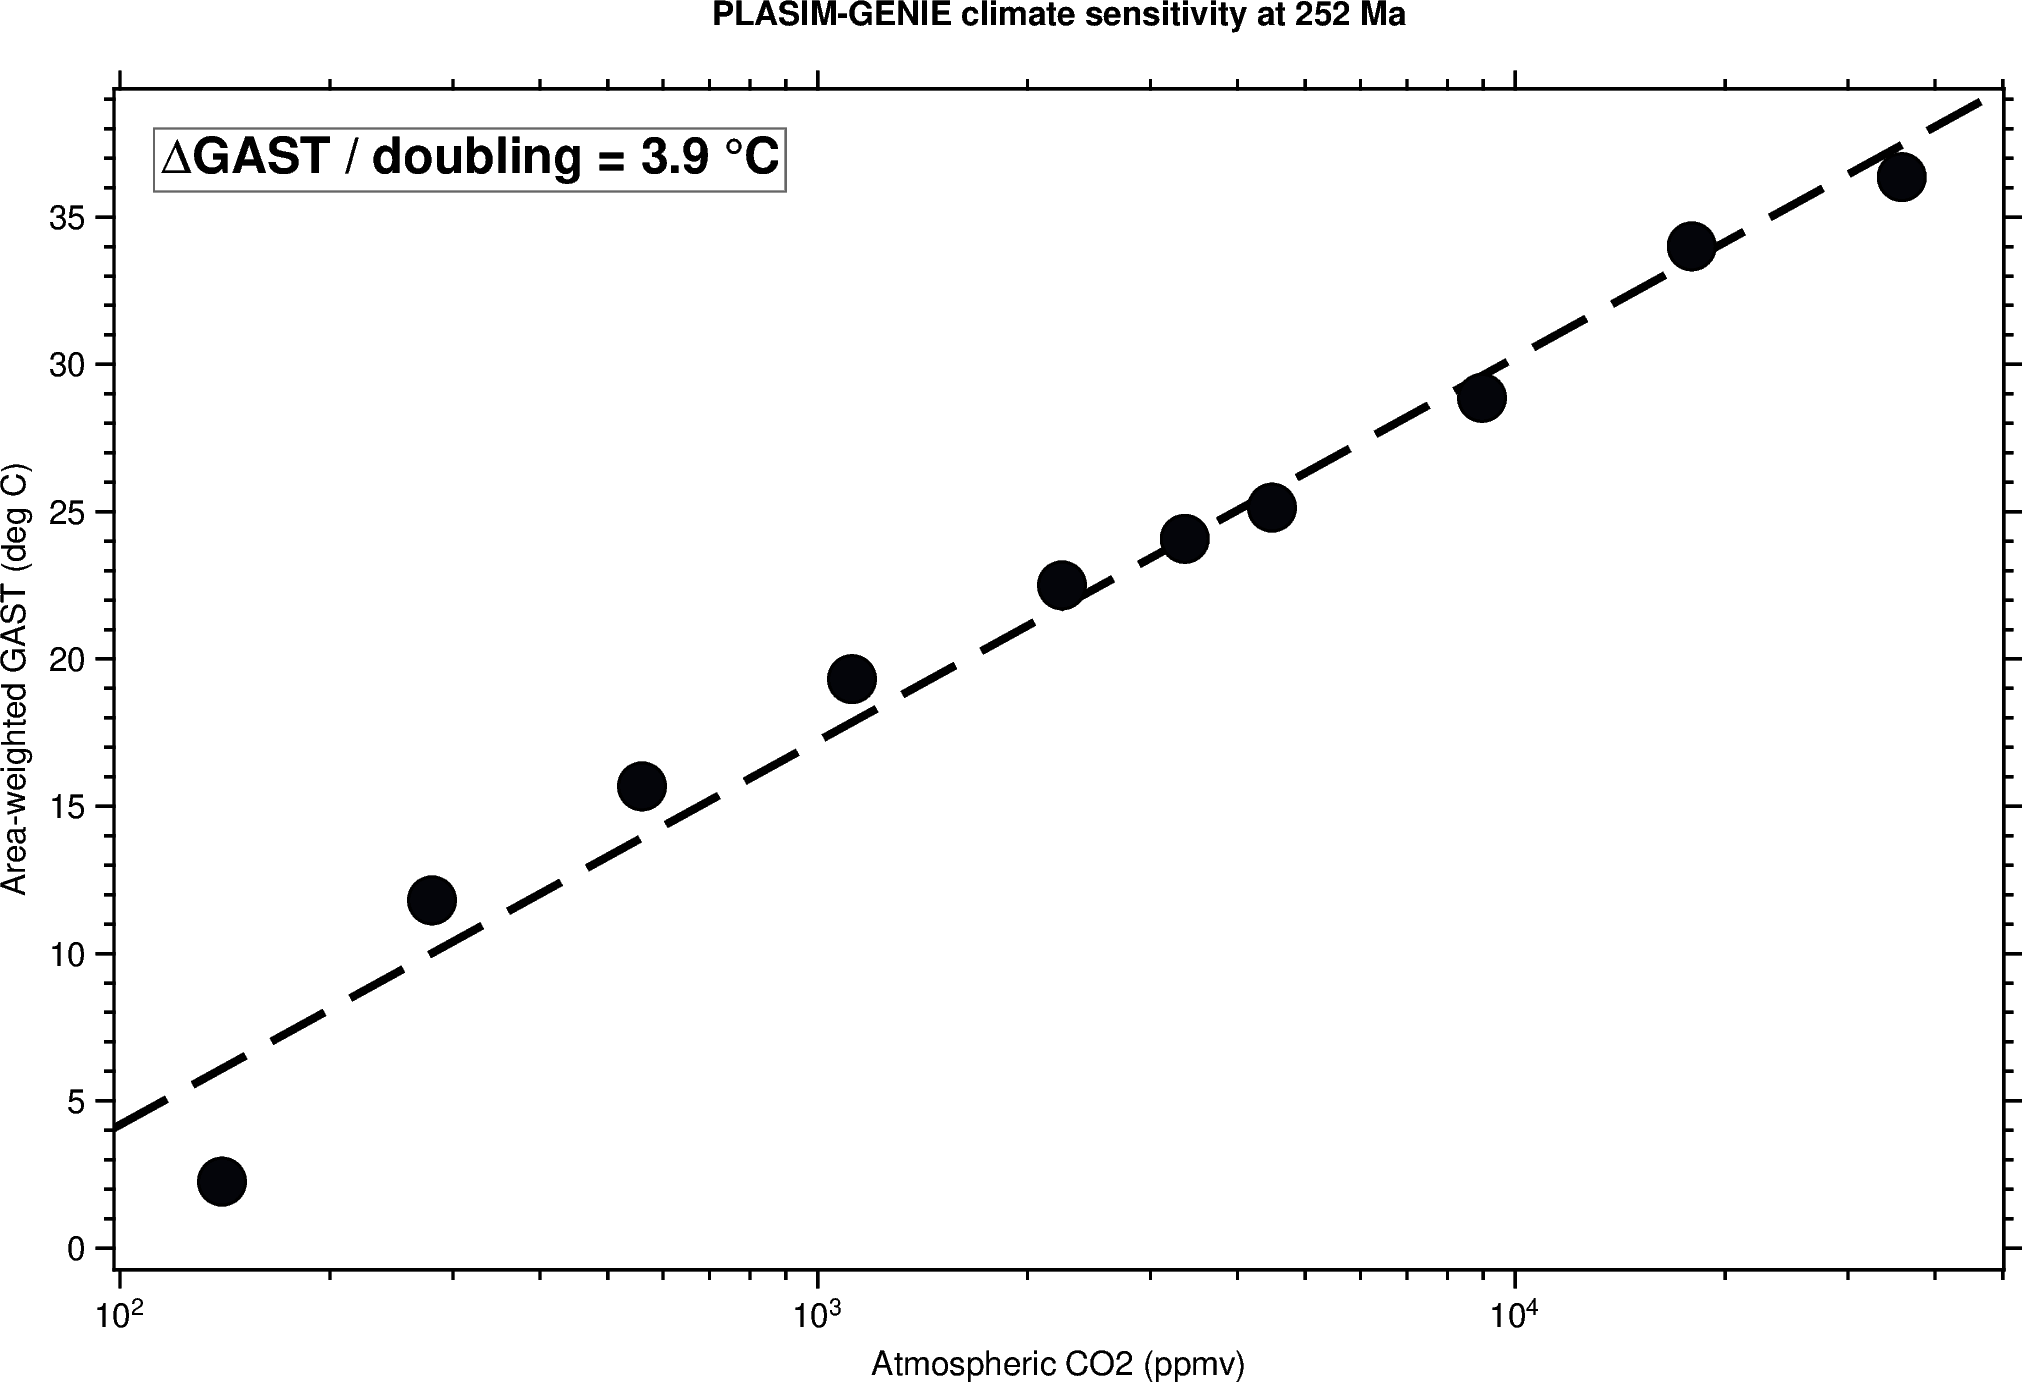


GAST range: 2.3°C (140 ppm) — 36.4°C (35840 ppm)
Logarithmic climate sensitivity: 3.92 °C per CO₂ doubling


/usr/local/lib/python3.11/dist-packages/xarray/core/dataarray.py:6325: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
/usr/local/lib/python3.11/dist-packages/xarray/core/dataarray.py:6446: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().


In [6]:
# Cell 5 — sensitivity scatter + fit (pure pyGMT)
# Area-weighted GAST per CO2 level
weights = np.cos(np.deg2rad(lats))
weights_norm = weights / weights.sum()
gast = (ds["SAT"] * xr.DataArray(weights_norm, dims=("latitude",), coords={"latitude": lats})).sum(dim=("latitude","longitude")) / ds.sizes["longitude"]

# Linear regression: GAST = a + b * ln(CO2)
co2 = ds.co2_ppm.values.astype(float)
lnco2 = np.log(co2)
b, a = np.polyfit(lnco2, gast.values, 1)
ECS_per_doubling = b * np.log(2)

# Axis extent (log CO2 axis)
xmin = float(co2.min()) * 0.7
xmax = float(co2.max()) * 1.4
ymin = float(gast.values.min()) - 3.0
ymax = float(gast.values.max()) + 3.0

fig = pygmt.Figure()
fig.basemap(region=[xmin, xmax, ymin, ymax], projection="X16cl/10c",
            frame=["WSne+tPLASIM-GENIE climate sensitivity at 252 Ma",
                   "xa1pf3p+lAtmospheric CO2 (ppmv)",
                   "ya5f1+lArea-weighted GAST (deg C)"])
# Regression line
co2_line  = np.geomspace(xmin, xmax, 200)
gast_line = a + b * np.log(co2_line)
fig.plot(x=co2_line, y=gast_line, pen="1.8p,black,dashed")
# Data points coloured by CO2 rank (batlowK, matches SET-scale palette)
pygmt.makecpt(cmap="batlowK",
              series=[float(co2.min()), float(co2.max())],
              continuous=True, log=True)
fig.plot(x=co2, y=gast.values, style="c0.4c",
         fill=co2, cmap=True, pen="0.6p,black")
# Slope annotation, inside upper-left of the frame
fig.text(x=xmin, y=ymax, offset="0.4c/-0.4c",
         justify="TL", no_clip=True,
         text=f"@~D@~GAST / doubling = {ECS_per_doubling:.1f} @~\260@~C",
         font="12p,Helvetica-Bold,black",
         fill="white", pen="0.4p,gray40")
fig.show(width=720)

print(f"\nGAST range: {gast.values.min():.1f}\xb0C ({co2[gast.argmin().item()]:.0f} ppm) — "
      f"{gast.values.max():.1f}\xb0C ({co2[gast.argmax().item()]:.0f} ppm)")
print(f"Logarithmic climate sensitivity: {ECS_per_doubling:.2f} \xb0C per CO\u2082 doubling")

## 5. Model spin-up — energy-balance time series

Confirms the ensemble has reached equilibrium before we trust the last-year snapshot.
The thermal-outgoing curve should flatten by ~year 1500 for every CO₂ level.

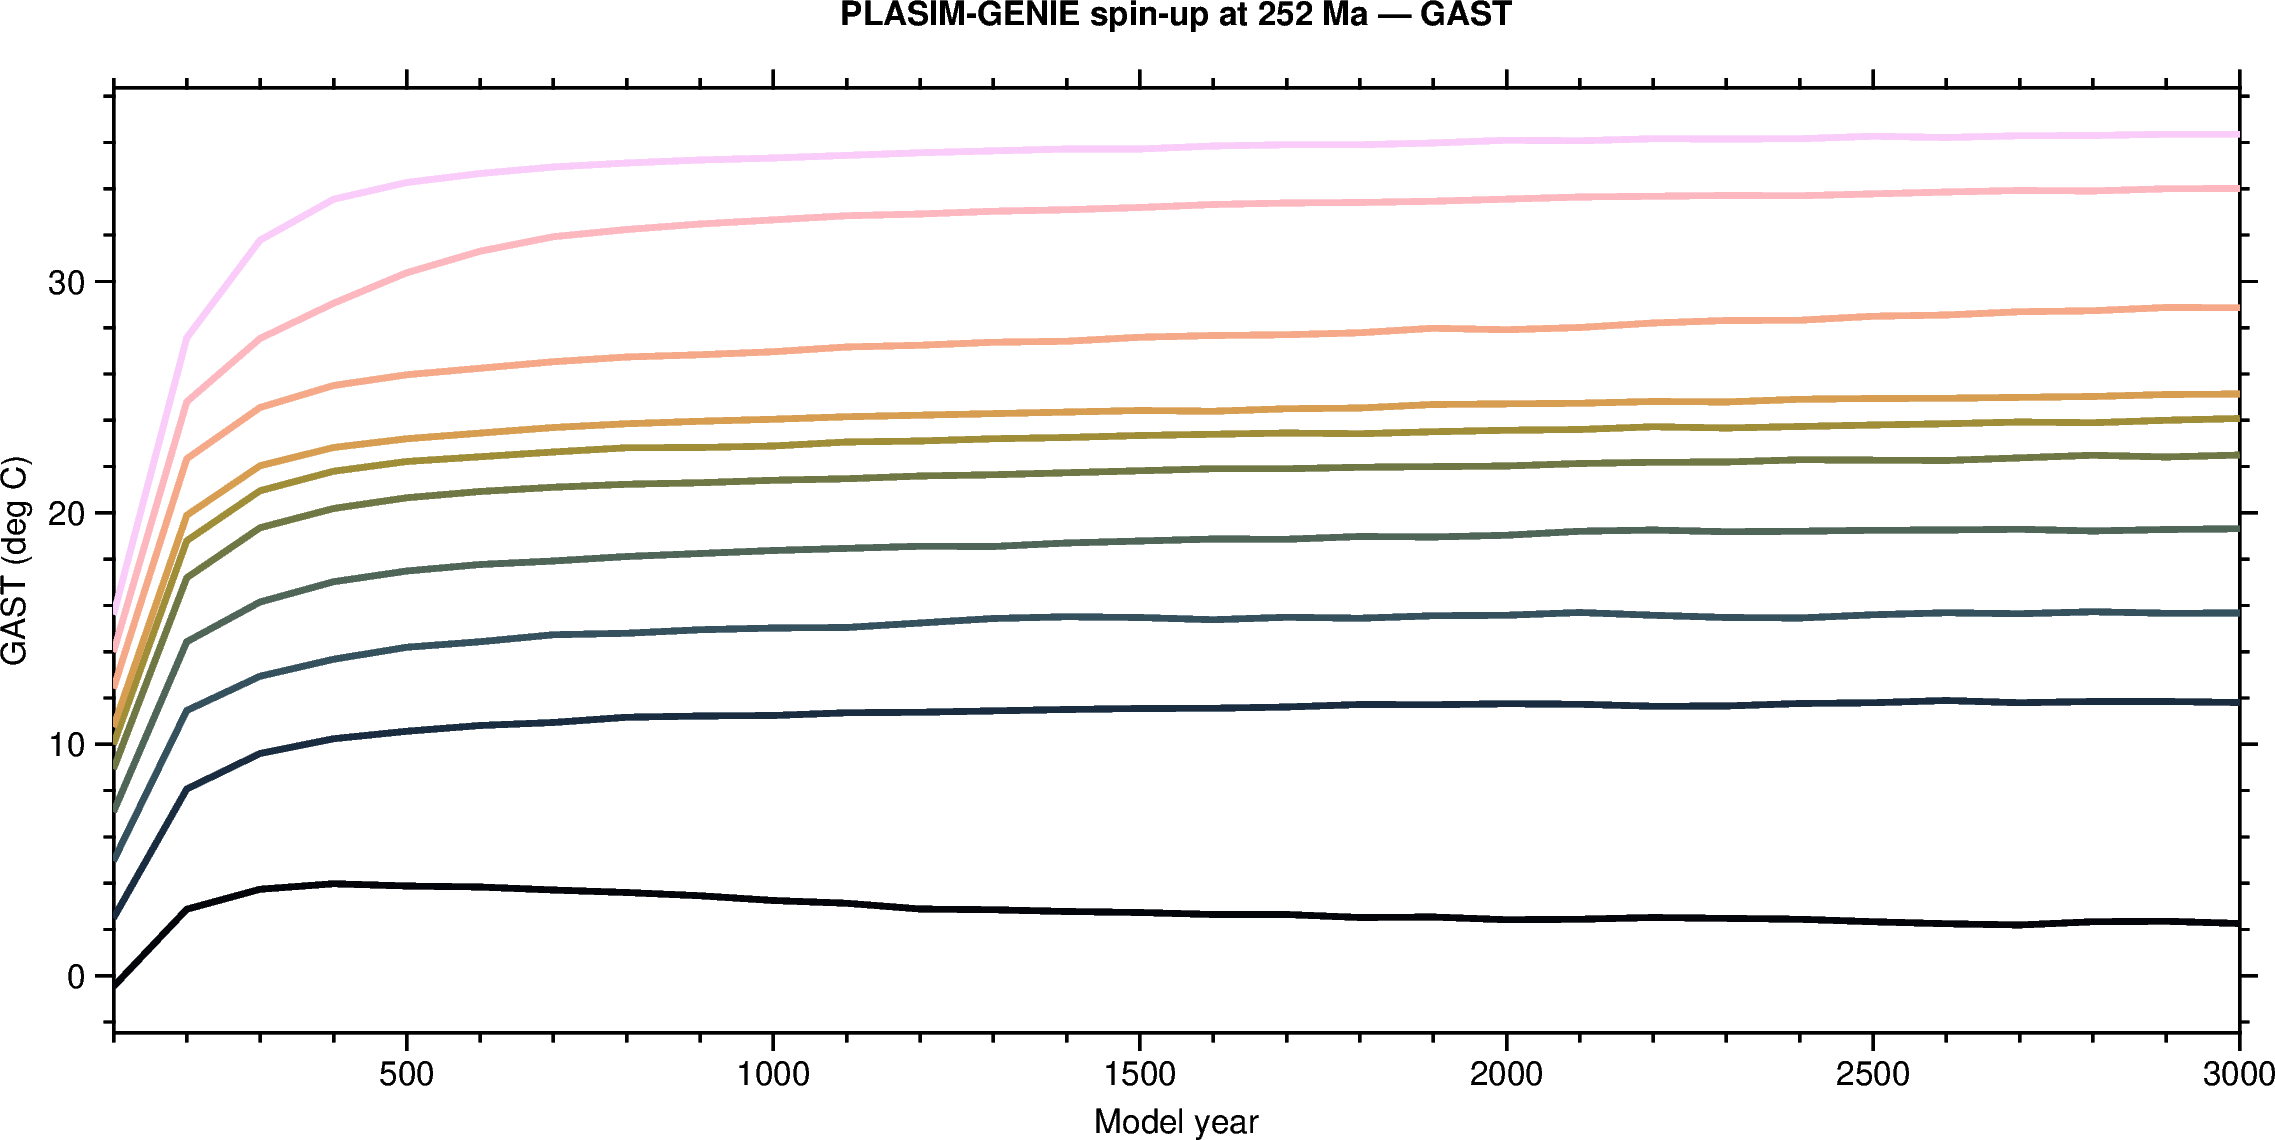

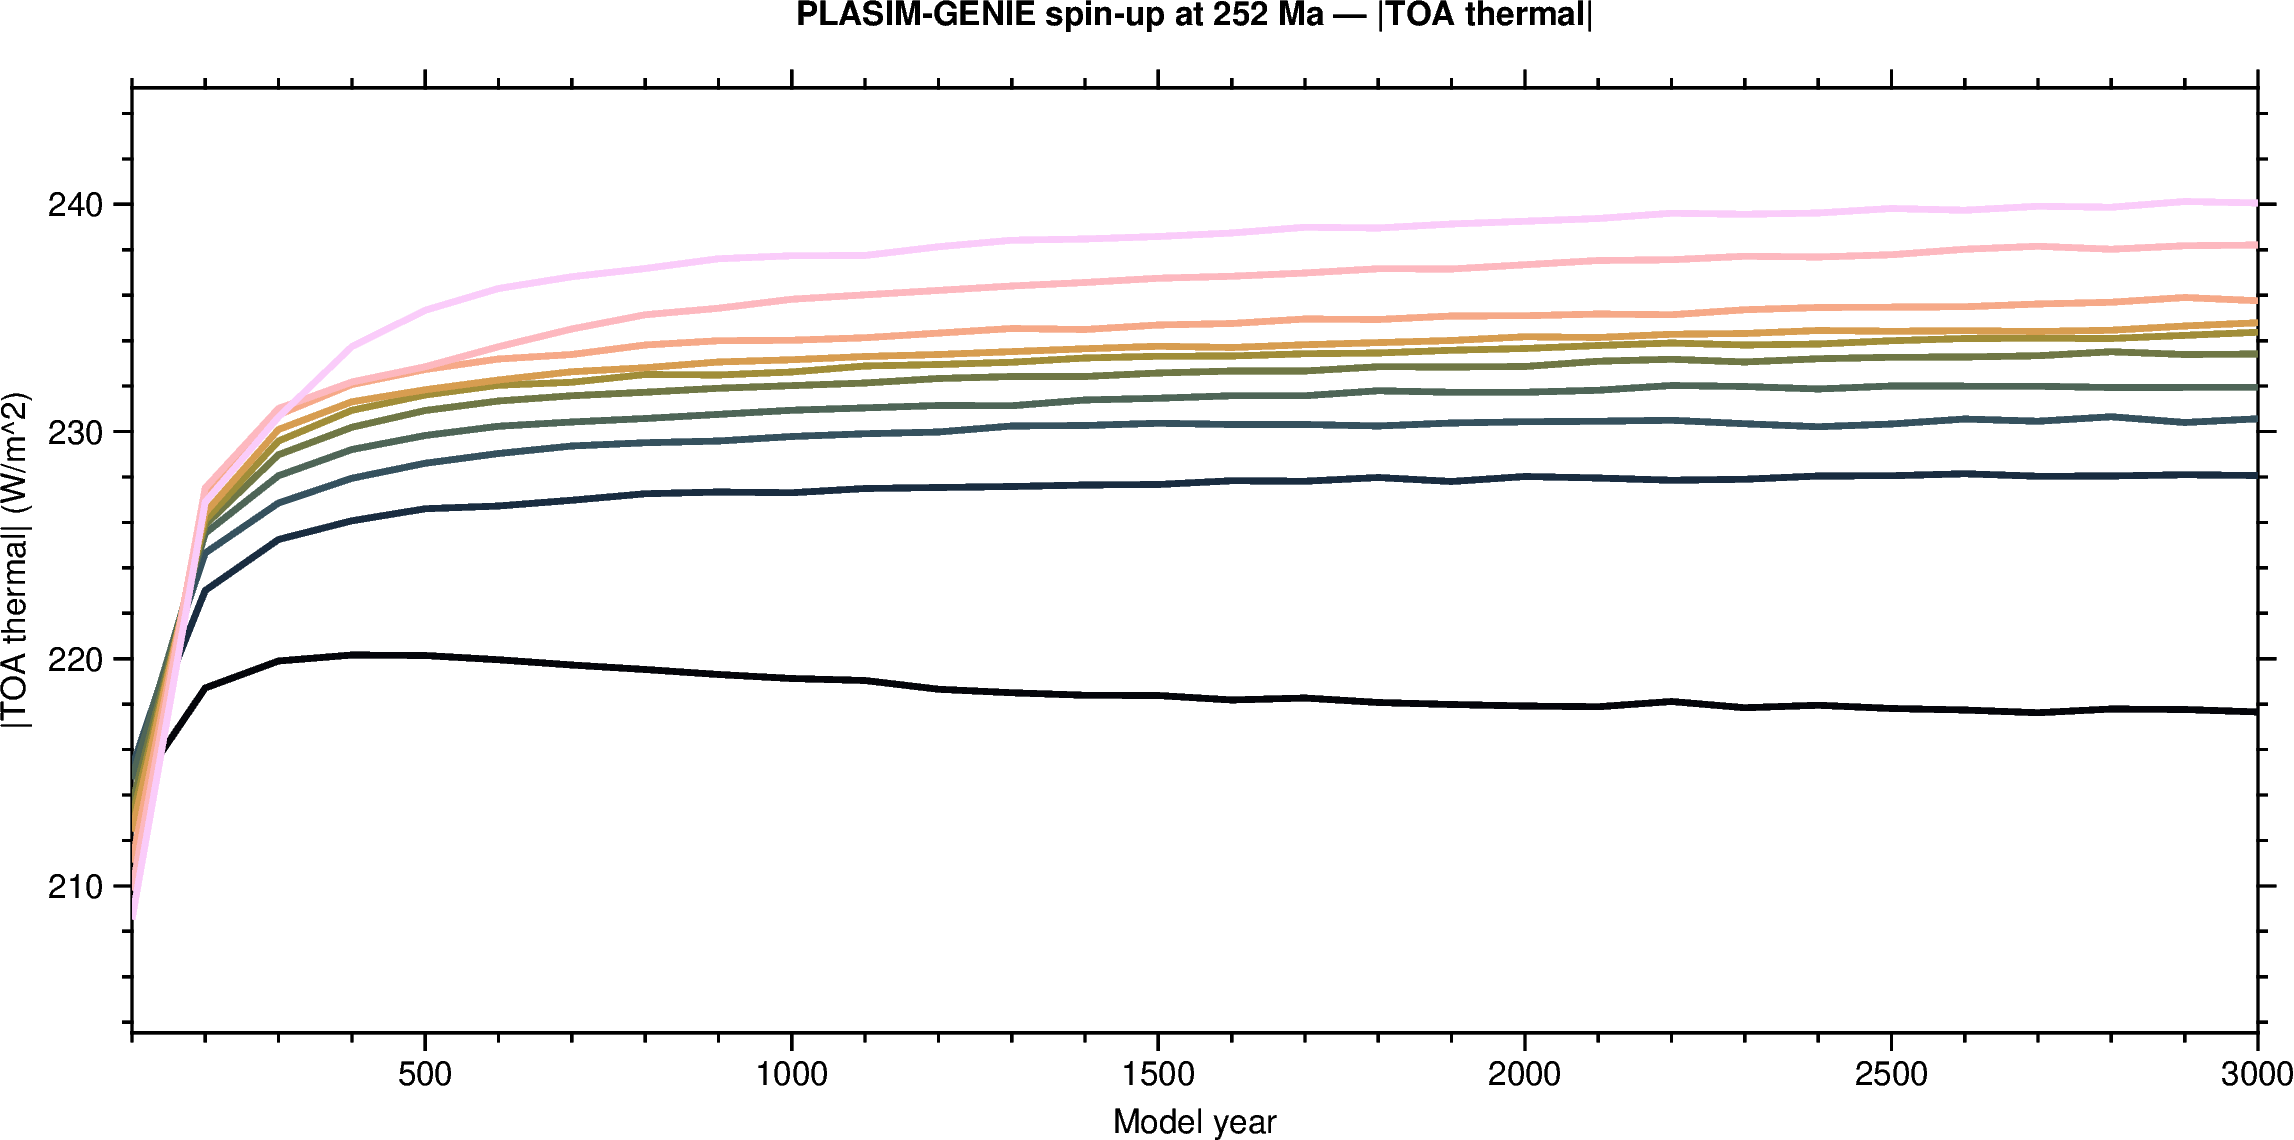

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


colorbar [ERROR]: CPT <stdin> has no z-slices!


[Session pygmt-session (142)]: Error returned from GMT API: GMT_CPT_READ_ERROR (8)


[Session pygmt-session (142)]: Error returned from GMT API: GMT_CPT_READ_ERROR (8)


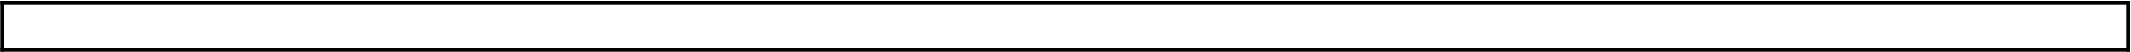

In [7]:
# Cell 6 — spin-up curves (pure pyGMT, two stacked panels)
sp = xr.open_dataset("data/plasim_genie_permian/plasim_genie_252Ma_spinup.nc")
# Spin-up scalars were area-weighted at source but never divided by n_lon.
# Divide here so GAST reads in °C and |TOA thermal| reads in W m⁻².
_n_lon = int(sp.sizes.get("longitude", 64))

co2_vals    = sp.co2_ppm.values
norm_levels = np.linspace(0, 1, len(co2_vals))
years       = np.asarray(sp.year.values, dtype=float)

def _hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))

# --- Panel 1: GAST vs year ---
gast_all = (sp["GAST"] / _n_lon).values  # shape (n_co2, n_year)
ymin = float(np.nanmin(gast_all)) - 2.0
ymax = float(np.nanmax(gast_all)) + 2.0

fig = pygmt.Figure()
fig.basemap(region=[float(years.min()), float(years.max()), ymin, ymax],
            projection="X18c/8c",
            frame=["WSne+tPLASIM-GENIE spin-up at 252 Ma — GAST",
                   "xaf+lModel year",
                   "yaf+lGAST (deg C)"])
for i, co2 in enumerate(co2_vals):
    colour = _hex(base(norm_levels[i])[:3])
    fig.plot(x=years, y=gast_all[i], pen=f"1.5p,{colour}")
fig.show(width=800)

# --- Panel 2: |TOA thermal| vs year ---
toa_all = (sp["top_thermal_abs"] / _n_lon).values
ymin = float(np.nanmin(toa_all)) - 5.0
ymax = float(np.nanmax(toa_all)) + 5.0

fig = pygmt.Figure()
fig.basemap(region=[float(years.min()), float(years.max()), ymin, ymax],
            projection="X18c/8c",
            frame=["WSne+tPLASIM-GENIE spin-up at 252 Ma — |TOA thermal|",
                   "xaf+lModel year",
                   "yaf+l|TOA thermal| (W/m^2)"])
for i, co2 in enumerate(co2_vals):
    colour = _hex(base(norm_levels[i])[:3])
    fig.plot(x=years, y=toa_all[i], pen=f"1.5p,{colour}")
fig.show(width=800)

# CO2-ramp colourbar (log-scaled) shown once below both panels
pygmt.makecpt(cmap="batlowK",
              series=[float(co2_vals.min()), float(co2_vals.max())],
              continuous=True, log=True)
fig = pygmt.Figure()
fig.basemap(region=[0, 1, 0, 0.01], projection="X18c/0.4c", frame="lrbt")
fig.colorbar(frame="af+lAtmospheric CO2 (ppmv)",
             position="JMC+w14c/0.35c+h")
fig.show(width=800)

## Extend this

- **Pull a different equilibrium variable.** The bundle includes `sea_ice_cover`, `snow_depth`, `surface_albedo`. Repeat the 3-panel map with `sea_ice_cover` to see the ice-margin retreat through the CO₂ sweep.
- **Different paleogeography ensemble.** Andrew Merdith maintains a full Cryogenian ensemble (575–800 Ma × 5 CO₂ × 4 paleogeography parameter sets). Same notebook framework; swap in those nc files and rerun.

## References

- Mills, B.J.W., Donnadieu, Y., Goddéris, Y. (2021). Spatial continuous integration of Phanerozoic global biogeochemistry and climate. *Gondwana Research* 100, 73-86.
- **pySCION.** Merdith, A.S., Gernon, T.M., Maffre, P., Donnadieu, Y., Goddéris, Y., Longman, J., Müller, R.D. & Mills, B.J.W. (2025). Phanerozoic icehouse climates as the result of multiple solid-Earth cooling mechanisms. *Science Advances* 11(7), eadm9798. https://doi.org/10.1126/sciadv.adm9798 — Python implementation of SCION (uses SCION only; not cGENIE/PLASIM). (Python implementation of SCION with coupled climate-system components is the pipeline that computed the bundled ensemble.)
- Fraedrich, K., Jansen, H., Kirk, E., Luksch, U., Lunkeit, F. (2005). The Planet Simulator: Towards a user friendly model. *Meteorologische Zeitschrift* 14, 299-304. (PLASIM atmosphere.)
- Edwards, N.R., Marsh, R. (2005). Uncertainties due to transport-parameter sensitivity in an efficient 3-D ocean-climate model. *Climate Dynamics* 24, 415-433. (GOLDSTEIN ocean.)
- Crameri, F. (2018). Scientific colour maps. *Zenodo*. (`cmcrameri` palette package.)
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515

- Müller, R.D., Flament, N., Cannon, J., Tetley, M.G., Williams, S.E., Cao, X., Bodur, Ö.F., Zahirovic, S. & Merdith, A. (2022). A tectonic-rules-based mantle reference frame since 1 billion years ago. *Solid Earth* 13(7), 1127–1159. https://doi.org/10.5194/se-13-1127-2022
